In [ ]:
import os, sys, importlib, pathlib
import pandas as pd
from pathlib import Path
sys.path.append (os.path.abspath(".."))

import statsmodels.api as sm
import statsmodels.formula.api as smf


# my utils
from utils import fa
from utils import modeling
from utils import preprocess_listings
from utils.preprocess_listings import desc_catORnum

# 标准版存档V0：

LABELS_EN=[
            'open to different cultures', 'cosmopolitan','international view', 'cultural exchange',
            'personal life', 'life experiences', 'divers interests', 'hobbies', 'enjoy life',
            'meet new people', 'welcoming', 'friendly', 'sociable', 'interpersonal interaction',
            'thoughtful service', 'attentive to needs', 'willing to help', 'responsive',
            'fan of Airbnb', 'Airbnb community','love Airbnb', 'travel with Airbnb'
        ]
DICT_FACTOR_ITEMS={"ouverture":['open to different cultures', 'cosmopolitan','international view', 'cultural exchange'],
                   "authenticité":['personal life', 'life experiences', 'divers interests', 'hobbies', 'enjoy life'],
                   "sociabilité":['meet new people', 'welcoming', 'friendly', 'sociable', 'interpersonal interaction'],
                   "auto_promotion":['thoughtful service', 'attentive to needs', 'willing to help', 'responsive'],
                   "exemplarité":['fan of Airbnb', 'Airbnb community','love Airbnb', 'travel with Airbnb']}

tactics_bio=[
    "ouverture", "authenticité","sociabilité","auto_promotion","exemplarité", 
]
def p_to_sig(p):
    if p < 0.001: return '***'
    elif p < 0.01: return '**'
    elif p < 0.05: return '*'
    elif p < 0.1: return '.'
    else: return ''

In [6]:
# path_df="../data_processed\listings_tactics_bio_vis-paris_london-2306_2406_ols.csv"
path_df=r"../data_processed\listings_tactics_bio_vis-paris_london-2306_2312_2406.csv"
df_all=pd.read_csv(path_df)
print(df_all.shape)

C:\Users\yeliu\AppData\Local\Temp\ipykernel_20272\571702545.py:3: DtypeWarning: Columns (6,68,115) have mixed types. Specify dtype option on import or set low_memory=False.
  df_all=pd.read_csv(path_df)


(266852, 125)


In [7]:
df_all[tactics_bio]=df_all[tactics_bio].fillna(0)
print(df_all[tactics_bio].isna().value_counts())


ouverture  authenticité  sociabilité  auto_promotion  exemplarité
False      False         False        False           False          266852
Name: count, dtype: int64


In [8]:
# df_all["time"]=df_all["time"].astype(str)
# df_all['trend'] = df_all['time'].map({'2306':0, "2312":1, '2406':2})#***
print(df_all[['in_paris',"time","trend","post"]].value_counts(dropna=False))

in_paris  time  trend  post
1         2406  2      1       62738
0         2406  2      1       49856
          2312  1      0       43172
          2306  0      0       42356
1         2312  1      0       35829
          2306  0      0       32901
Name: count, dtype: int64


## pre trend check

In [5]:
df_pre=df_all[df_all['time']!="2406"]
print(df_pre.shape)
print(df_pre[['time','in_paris']].value_counts())

(266852, 125)
time  in_paris
2406  1           62738
      0           49856
2312  0           43172
2306  0           42356
2312  1           35829
2306  1           32901
Name: count, dtype: int64


In [147]:
## pre trend check!!!

# booking_rate_l90d
df=df_pre.copy()
formula= (" booking_rate_l90d ~ C(host_identity_verified)  + review_scores_rating + has_rating + number_of_reviews_ltm +"
            "C(host_is_superhost) +"
            "years_since_host + professional_host + "
            "host_response_rate + C(host_response_time)+ "
            "has_text + lang_fr + lang_en + text_length +"
            "price  + availability_90 + C(room_type) + C(instant_bookable) + "
            "in_paris * C(time)"
)
model=smf.ols(formula, data=df).fit(cov_type="HC1")#robust standard errors
summary=model.summary()
print(summary)


                            OLS Regression Results                            
Dep. Variable:      booking_rate_l90d   R-squared:                       0.398
Model:                            OLS   Adj. R-squared:                  0.398
Method:                 Least Squares   F-statistic:                     2802.
Date:                Tue, 07 Apr 2026   Prob (F-statistic):               0.00
Time:                        12:54:56   Log-Likelihood:                 88109.
No. Observations:              266852   AIC:                        -1.762e+05
Df Residuals:                  266824   BIC:                        -1.759e+05
Df Model:                          27                                         
Covariance Type:                  HC1                                         
                                                  coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------

# tactic~


## + trend: "C(time) + in_paris*trend + in_paris * post"


In [ ]:

# ✔ 1. C(time) # 控制所有城市共同的时间变化（宏观趋势）
# ✔ 2. in_paris * trend # 允许 Paris 和 London 有不同的趋势（解决你发现的不平行问题）
# ✔ 3. in_paris * post # 👉 在控制趋势差异之后，识别 JO 的“额外冲击”

# 在控制了城市固定差异、时间效应以及城市特定趋势（city-specific trends）之后，
# in_paris × post 捕捉了 2024年巴黎奥运会 对 Paris 相对于 London 的“额外变化”（differential change）

# 优点： 清晰、好解释（有一个系数）
# 缺点： 强结构假设的 DiD（parametric DiD）：
# pre-trend 是线性的
# treatment effect 是“一个跳跃 + 一个趋势修正”


In [ ]:

def run_tactic_model_by_trend(df, y):
    formula= (f"{y} ~ C(host_identity_verified)  + review_scores_rating + has_rating +"
            "number_of_reviews_ltm + "
            "C(host_is_superhost) +"
            "years_since_host + professional_host + "
            "host_response_rate +  C(host_response_time)+"
            "has_text + lang_en + lang_fr + text_length+"
            "price  + availability_90 + C(room_type) + C(instant_bookable) + "
            
            # "ouverture + authenticité + sociabilité + auto_promotion + exemplarité +"
            # "C(host_picture_type) +"
            # "pic_no_person + pic_pro_style + pic_life_style +"
            # " is_smiling + "
            # "C(age_class) + C(gender) +"
            "C(time) + in_paris*trend + in_paris * post"
    )
    model_tactic=smf.ols(formula, data=df).fit()
    # summary=model_tactic.summary()
    # print(summary)
    return model_tactic


results=[]
for var in tactics_bio:
    print(var)
    model=run_tactic_model_by_trend(df, var)
    term="in_paris:post"
    coef = model.params[term]
    se = model.bse[term]
    pval = model.pvalues[term]
    
    results.append({
        "variable": var,
        "coef": coef,
        "se": se,
        "pval": pval,
        "sig": p_to_sig(pval),
        "ci_low": coef - 1.96 * se,
        "ci_high": coef + 1.96 * se
    })
results_df = pd.DataFrame(results)


ouverture
authenticité
sociabilité
auto_promotion
exemplarité


In [45]:
results_df

,variable,coef,se,pval,sig,ci_low,ci_high
0,ouverture,-0.009624,0.010803,0.373031,,-0.030798,0.011551
1,authenticité,-0.015611,0.011191,0.163017,,-0.037545,0.006323
2,sociabilité,-0.009865,0.011565,0.393671,,-0.032532,0.012803
3,auto_promotion,0.042751,0.010544,0.000050,***,0.022086,0.063417
4,exemplarité,0.044509,0.011202,0.000071,***,0.022553,0.066464


<Figure size 640x480 with 0 Axes>

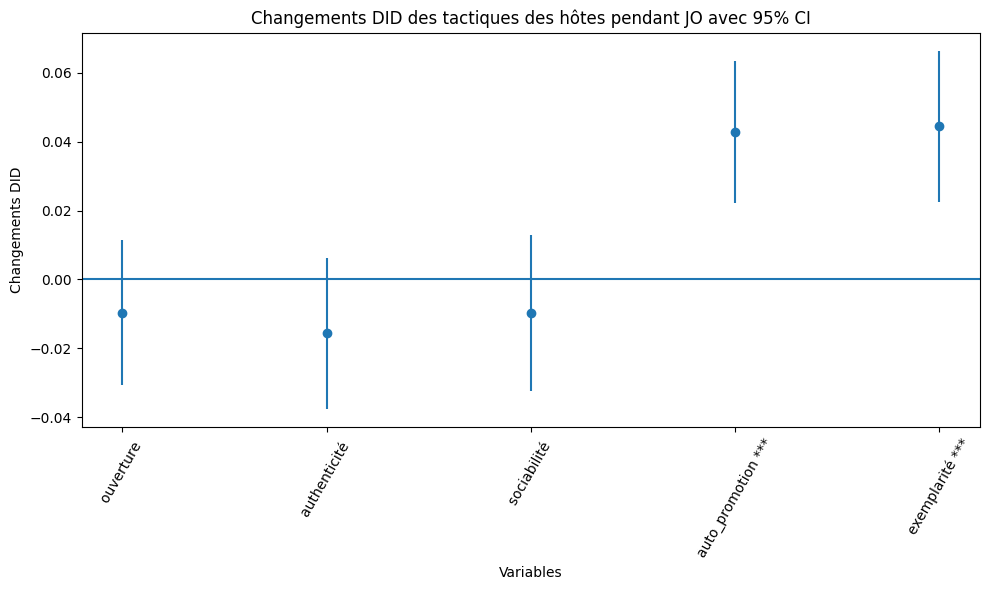

In [46]:
# did effect
import pandas as pd
import matplotlib.pyplot as plt

results_df['label']=results_df['variable']+" "+results_df['sig']

plt.figure()
plt.figure(figsize=(10,6))
plt.errorbar(
    results_df["label"],
    results_df["coef"],
    yerr=[results_df["coef"] - results_df["ci_low"],
          results_df["ci_high"] - results_df["coef"]],
    fmt='o', 
)
plt.axhline(0)  # 0线（是否显著）
plt.xlabel("Variables")
plt.ylabel("Changements DID")
plt.title("Changements DID des tactiques des hôtes pendant JO avec 95% CI")
plt.xticks(rotation=60)
plt.tight_layout()
plt.show()

## event study :C(time) + in_paris * C(time)


In [ ]:
## event study :C(time) + in_paris * C(time)
# 不假设差异趋势是线性的
# # 弱假设 / 非参数 DiD（event study）：[更加稳健]
# 每个时间点可以自由变化,不强制趋势形状
##==允许：2312 下跌，2406 反弹，不规则变化

# C(time)固定时间变化（季节，整体增长）
# 交互项：paris(相对于london)[在每个时间点]的额外变化

# | 时间   | Paris 相对 London 的差异 |
# | ---- | ------------------- |
# | 2306 | baseline（被省略）     |
# | 2312 | β₁（pre-trend）       |
# | 2406 | β₂（JO + trend）      |
# JO effect ≈ β_2406 - β_2312 (24差异减去稳定差异==jo额外差异)

# 线性组合计算β_2406 - β_2312 = 0 ?


##结果差异，不仅因为数据不稳定，还有模型假设的差异

In [9]:
# ouverture ~ controls + tactics + C(time) + in_paris * C(time)

def run_tactic_model_by_time(df, y):
    formula= (f"{y} ~ C(host_identity_verified)  + review_scores_rating + has_rating +"
            "number_of_reviews_ltm + "
            "C(host_is_superhost) +"
            "years_since_host + professional_host + "
            "host_response_rate +  C(host_response_time)+"
            "has_text + lang_en + lang_fr + text_length+"
            "price  + availability_90 + C(room_type) + C(instant_bookable) + "
            "C(time) + in_paris * C(time)"
    )
    model_tactic=smf.ols(formula, data=df).fit()
    return model_tactic


df=df_all.copy()
model_tactic=run_tactic_model_by_time(df, y="authenticité")
print(model_tactic.summary())

                            OLS Regression Results                            
Dep. Variable:           authenticité   R-squared:                       0.169
Model:                            OLS   Adj. R-squared:                  0.169
Method:                 Least Squares   F-statistic:                     2007.
Date:                Tue, 07 Apr 2026   Prob (F-statistic):               0.00
Time:                        17:02:00   Log-Likelihood:            -2.6399e+05
No. Observations:              266852   AIC:                         5.280e+05
Df Residuals:                  266824   BIC:                         5.283e+05
Df Model:                          27                                         
Covariance Type:            nonrobust                                         
                                                  coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------

In [39]:
# event study 图：Paris 相对于 London，在不同时间点的“动态差异路径”

import pandas as pd
import matplotlib.pyplot as plt

def get_event_study_data(model, var):
    params = model.params
    bse = model.bse
    pvalues=model.pvalues
    
    # 提取 interaction terms
    data = pd.DataFrame({
        "coef": params,
        "se": bse,
        'pval':pvalues
    }).reset_index()

    data.columns = ["variable", "coef", "se", "pval"]

    # 只保留 in_paris × time
    data = data[data["variable"].str.contains("in_paris:C\\(time\\)")]
    
    # 提取时间点
    data["time"] = data["variable"].str.extract(r"T\.(\d+)")

    # 排序
    data = data.sort_values("time")

    # 置信区间
    data["ci_low"] = data["coef"] - 1.96 * data["se"]
    data["ci_high"] = data["coef"] + 1.96 * data["se"]
    
    # baseline（2306 = 0）
    baseline = pd.DataFrame({
        "time": ["2306"],
        "coef": [0],
        "ci_low": [0],
        "ci_high": [0]
    })

    data = pd.concat([baseline, data], ignore_index=True)

    # 转 numeric
    data["time"] = pd.to_numeric(data["time"])
    data = data.sort_values("time")
    data['time']=data['time'].astype(str)
    # display(df)
    data['variable']=var
    data['sig']=data['pval'].apply(p_to_sig)        
    data['label']=data['time']+' '+data['sig']        
    return data


data=get_event_study_data(model_tactic, var="authenticité")
display(data)

,time,coef,ci_low,ci_high,variable,se,pval,sig,label
0,2306,0.000000,0.000000,0.000000,authenticité,NaN,NaN,,2306
1,2312,0.029654,0.016556,0.042753,authenticité,0.006683,9.113254e-06,***,2312 ***
2,2406,0.043697,0.031511,0.055884,authenticité,0.006218,2.099537e-12,***,2406 ***


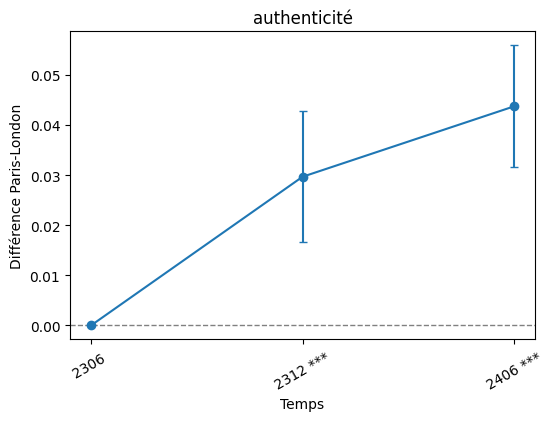

In [11]:

df=data.copy()

var="authenticité"

fig, ax=plt.subplots(figsize=(6, 4))

# strategies = df["variable"].unique()
# for var in strategies:
    
sub = df[df["variable"] == var].copy()

# 确保排序
sub = sub.sort_values("time")

# baseline处理（2306 = 0）
if (sub["time"] == '2306').any():
    sub.loc[sub["time"] == '2306', "coef"] = 0
    sub.loc[sub["time"] == '2306', "ci_low"] = 0
    sub.loc[sub["time"] == '2306', "ci_high"] = 0

# 置信区间errorbar
ax.errorbar(
    # sub['time'],
    sub['label'],
    sub["coef"],
    yerr=[
        sub["coef"] - sub["ci_low"],
        sub["ci_high"] - sub["coef"]
    ],
    fmt='-o',       # 👈 线 + 点
    capsize=3,
    # label=var, 
    # color=colors[i]
)

hline_v=0
ax.axhline(hline_v, linestyle="--", color="gray", linewidth=1)

ax.set_title(var)
ax.set_xlabel("Temps")
ax.set_ylabel('Différence Paris-London')
ax.tick_params(axis='x', rotation=30)

In [40]:
df=df_all.copy()
data_list=[]
for i, y in enumerate(tactics_bio):
    # if i >1:
    #     break  
    print (i, y)
    model=run_tactic_model_by_time(df, y)
    data = get_event_study_data(model, var=y)
    data_list.append(data)
data_all=pd.concat(data_list, axis=0)
data_all

0 ouverture
1 authenticité
2 sociabilité
3 auto_promotion
4 exemplarité


,time,coef,ci_low,ci_high,variable,se,pval,sig,label
0,2306,0.000000,0.000000,0.000000,ouverture,NaN,NaN,,2306
1,2312,0.005668,-0.006977,0.018313,ouverture,0.006452,3.796275e-01,,2312
2,2406,0.001713,-0.010052,0.013477,ouverture,0.006002,7.753645e-01,,2406
0,2306,0.000000,0.000000,0.000000,authenticité,NaN,NaN,,2306
1,2312,0.029654,0.016556,0.042753,authenticité,0.006683,9.113254e-06,***,2312 ***
2,2406,0.043697,0.031511,0.055884,authenticité,0.006218,2.099537e-12,***,2406 ***
0,2306,0.000000,0.000000,0.000000,sociabilité,NaN,NaN,,2306
1,2312,0.022324,0.008787,0.035861,sociabilité,0.006906,1.228010e-03,**,2312 **
2,2406,0.034783,0.022189,0.047377,sociabilité,0.006426,6.193342e-08,***,2406 ***
0,2306,0.000000,0.000000,0.000000,auto_promotion,NaN,NaN,,2306


In [65]:
# import pandas as pd
# import matplotlib.pyplot as plt

# def plot_event_study(data, title="Event Study - Tactics Comparison"):
#     df=data.copy()
    
#     plt.figure(figsize=(8, 6))

#     strategies = df["variable"].unique()
#     for var in strategies:
#         sub = df[df["variable"] == var].copy()

#         # 确保排序
#         sub = sub.sort_values("time")

#         # baseline处理（2306 = 0）
#         if (sub["time"] == '2306').any():
#             sub.loc[sub["time"] == '2306', "coef"] = 0
#             sub.loc[sub["time"] == '2306', "ci_low"] = 0
#             sub.loc[sub["time"] == '2306', "ci_high"] = 0

#         # 画线
#         plt.plot(sub["time"], sub["coef"], marker="o", label=var)

#         # # 置信区间
#         # plt.fill_between(
#         #     sub["time"],
#         #     sub["ci_low"],
#         #     sub["ci_high"],
#         #     alpha=0.15
#         # )

#     # 参考线
#     plt.axhline(0, linestyle="--", color="black", linewidth=1)

#     # # JO标记（2406）
#     # plt.axvline('2406', linestyle="--", color="black", alpha=0.6)
#     # plt.text('2406', plt.ylim()[1]*0.8,"JO", color="black")

#     # 美化
#     plt.xlabel("Time")
#     plt.ylabel("Paris - London Effect")
#     plt.title(title)
#     plt.legend()
#     plt.tight_layout()

#     plt.show()
# plot_event_study(data_all, title="Event Study - Tactics Comparison")

# ## 每个时间点paris相对于london，额外变化的量==time:in_paris

# ## 2406:trend+jo的情况下，auth, soc,ouv增长减少，auto, exe增加

C:\Users\yeliu\AppData\Local\Temp\ipykernel_20272\3389431213.py:96: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
C:\Users\yeliu\AppData\Local\Temp\ipykernel_20272\3389431213.py:97: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


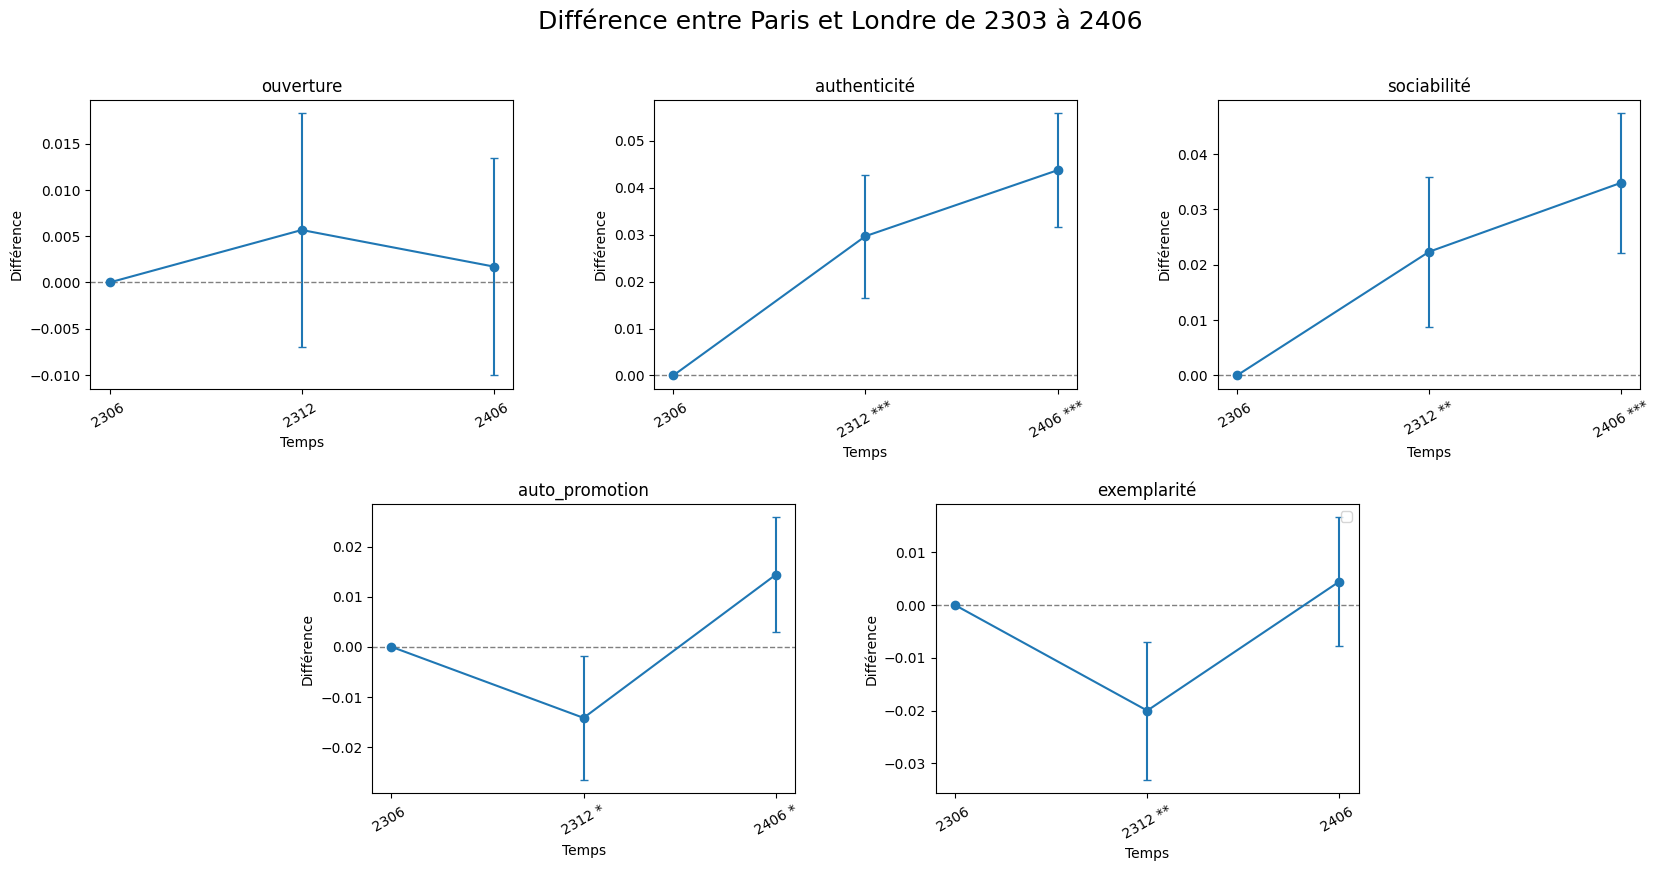

In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.gridspec as gridspec


# colors = sns.color_palette("tab20", 6)


def plot_one(data,i, var='authenticité'): 
    df=data.copy()
    ax=axes[i]

    # fig, ax=plt.subplots(figsize=(6, 4))

    # strategies = df["variable"].unique()
    # for var in strategies:
        
    sub = df[df["variable"] == var].copy()

    # 确保排序
    sub = sub.sort_values("time")

    # baseline处理（2306 = 0）
    if (sub["time"] == '2306').any():
        sub.loc[sub["time"] == '2306', "coef"] = 0
        sub.loc[sub["time"] == '2306', "ci_low"] = 0
        sub.loc[sub["time"] == '2306', "ci_high"] = 0
    
    # 置信区间errorbar
    ax.errorbar(
        # sub['time'],
        sub['label'],
        sub["coef"],
        yerr=[
            sub["coef"] - sub["ci_low"],
            sub["ci_high"] - sub["coef"]
        ],
        fmt='-o',       # 👈 线 + 点
        capsize=3,
        # label=var, 
        # color=colors[i]
    )

    hline_v=0
    ax.axhline(hline_v, linestyle="--", color="gray", linewidth=1)

    ax.set_title(var)
    ax.set_xlabel("Temps")
    ax.set_ylabel('Différence')
    ax.tick_params(axis='x', rotation=30)
    
    # JO标记（2406） 
    # ax.axvline('2406', linestyle="--", color="black", alpha=0.6)
       
    # # 美化
    # plt.xlabel("Temps")
    # plt.ylabel("Différence effet (Paris - London)")
    # plt.title(f"Etude d'événement de la tactique {var}")
    # plt.xticks(rotation=30)
    # plt.legend()
    # plt.tight_layout()

    # plt.show()
    
    

# --------------------layout-------------------
# 使用更细的列分辨率（2 行 × 6 列），方便把第二行两个图放在中间列
fig = plt.figure(figsize=(20,9))# sharey=True
gs = gridspec.GridSpec(2, 6, figure=fig, hspace=0.4, wspace=1)

axes = []
# 第一行三个：分别占两列宽 (0:2, 2:4, 4:6)
ax1 = fig.add_subplot(gs[0, 0:2])
ax2 = fig.add_subplot(gs[0, 2:4])
ax3 = fig.add_subplot(gs[0, 4:6])
axes.extend([ax1, ax2, ax3])

# 第二行两个：让它们居中，分别占中间的两列 (1:3 和 3:5)
ax4 = fig.add_subplot(gs[1, 1:3])
ax5 = fig.add_subplot(gs[1, 3:5])
axes.extend([ax4, ax5])

# 确保 tactics_vars 长度为 5（或小于等于 len(axes)）
n_to_plot = min(len(tactics_bio), len(axes))


for i, var in enumerate(tactics_bio):
    plot_one(data=data_all, i=i, var=var)
fig.suptitle(
        "Différence entre Paris et Londre de 2303 à 2406",
        fontsize=18,
        y=0.98
    )
plt.legend()
plt.tight_layout()
plt.show()

# 在event study，不对趋势形状做任何假设，如果不存在jo，我们认为2406的差异和2312一样，两个点处于一条水平线上
# 所以jo的效应偏离这条差异水平线
# 如果trend是线性的，2406没有jo的差异会落在延长线上，表示两地的差异不断扩大

### predict line+ counterfactual line

In [9]:
df_cf['time'].dtype

dtype('int64')

In [12]:
# df=df_all.copy()
# y='authenticité'
# model=run_tactic_model_by_time(df, y)

# ## (predicted) observed
# df["y_hat"] = model.predict(df)

# ## (predicted) cf:去掉paris*2406
# df_cf = df.copy()

# df_cf.loc[
#     (df_cf["in_paris"] == 1) & (df_cf["time"] == 2406),
#     "in_paris"
# ] = 0
# # 不能修改时间！“2024 仍然是 2024，但没有 JO”
# # 不能把C(time)[T:2406]改成C(time)[T:2312], 但是要去掉in_paris:C(time)[T.2406]，所以要让in_paris==0

# df["y_cf"] = model.predict(df_cf)


# display(df[['y_hat','y_cf']].describe())
# df.groupby(['time','in_paris'])[['y_hat','y_cf']].mean()

,y_hat,y_cf
count,266852.000000,266852.000000
mean,-0.176631,-0.159473
std,0.293230,0.296728
min,-2.061221,-2.061221
25%,-0.369994,-0.354998
50%,-0.151912,-0.135883
75%,0.047310,0.070680
max,0.778676,0.778676


y_hat      y_cf
time in_paris                    
2306 0        -0.181066 -0.181066
     1        -0.158274 -0.158274
2312 0        -0.204839 -0.204839
     1        -0.155755 -0.155755
2406 0        -0.216109 -0.216109
     1        -0.144402 -0.071422

In [ ]:
# ## XXXxxx
# df=df_all.copy()
# y='ouverture'
# model=run_tactic_model_by_time(df, y)

# ## (predicted) observed
# df["y_hat"] = model.predict(df)

# ## (predicted) cf:去掉paris*2406
# df_cf = df.copy()

# df_cf.loc[
#     (df_cf["in_paris"] == 1) & (df_cf["time"] == 2406),
#     "time"
# ] = 2312

# df["y_cf"] = model.predict(df_cf)

# display(df[['y_hat','y_cf']].describe())
# df.groupby(['time','in_paris'])[['y_hat','y_cf']].mean()


,y_hat,y_cf
count,266852.000000,266852.000000
mean,-0.100350,-0.121140
std,0.185314,0.187730
min,-1.531509,-1.531509
25%,-0.219187,-0.231403
50%,-0.077651,-0.094116
75%,0.040241,0.015325
max,0.407295,0.407295


y_hat      y_cf
time in_paris                    
2306 0        -0.111349 -0.111349
     1        -0.093083 -0.093083
2312 0        -0.111726 -0.111726
     1        -0.083193 -0.083193
2406 0        -0.113564 -0.113564
     1        -0.088205 -0.176636

In [20]:
df=df_all.copy()
y='authenticité'
model=run_tactic_model_by_time(df, y)

df["y_hat"] = model.predict(df)

# df_cf = df.copy()
##不改变时间，不改变地点，仅减去jo（交互项之差）

delta_2406 = model.params["in_paris:C(time)[T.2406]"]
delta_2312 = model.params["in_paris:C(time)[T.2312]"]

adjustment = delta_2406 - delta_2312

df["y_cf"] = df["y_hat"]

df.loc[
    (df["in_paris"]==1) & (df["time"]==2406),
    "y_cf"
] -= adjustment

display(df[['y_hat','y_cf']].describe())
agg=df.groupby(['time','in_paris'])[['y_hat','y_cf']].mean().reset_index()


,y_hat,y_cf
count,266852.000000,266852.000000
mean,-0.176631,-0.179932
std,0.293230,0.292927
min,-2.061221,-2.061221
25%,-0.369994,-0.373415
50%,-0.151912,-0.154947
75%,0.047310,0.042744
max,0.778676,0.778676


Text(0.5, 0, 'Temps')

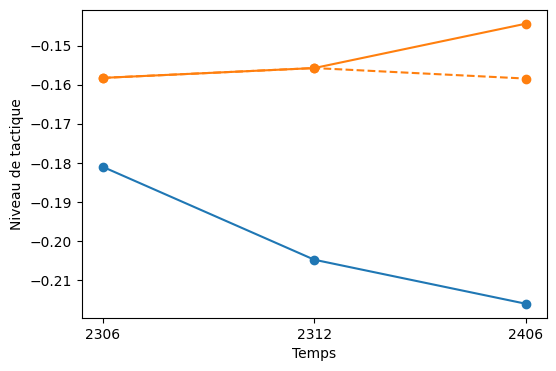

In [21]:
# agg=agg_all[agg_all['variable']==var]
    # display(agg)
    
fig, ax=plt.subplots(figsize=(6, 4))
# categorical mapping
times = sorted(agg["time"].unique())
time_map = {t: i for i, t in enumerate(times)}

paris = agg[agg["in_paris"] == 1]    
ax.plot(
    paris["time"].map(time_map),
    paris["y_hat"],
    marker="o",
    label="Observed (Paris)",
        color='tab:orange'
)

ax.plot(
    paris["time"].map(time_map),
    paris["y_cf"],
    marker="o",
    linestyle="--",
    label="Counterfactual  (Paris)",
    color='tab:orange'
)

control = agg[agg["in_paris"] == 0]
ax.plot(
    control["time"].map(time_map),
    control["y_hat"],
    marker="o",
    # alpha=0.4,
    label="Observed (London)",
    color='tab:blue'
)

# event line
# ax.axvline(time_map[2406], color="red", linestyle="--")
# x-axis as labels (equal spacing!)
ax.set_xticks(list(time_map.values()))
ax.set_xticklabels(list(time_map.keys()))

# ax.legend()

# var_sig=p_to_sig(pval_dict.get(var))
# ax.set_title(f"{var} {var_sig}")
ax.set_ylabel("Niveau de tactique")
ax.set_xlabel("Temps")
# ax.set_ylabel("Outcome")
# break

In [35]:
def get_jo_effect(model, var):
        test = model.t_test(
            "in_paris:C(time)[T.2406] - in_paris:C(time)[T.2312] = 0"
        )
        return  {
            'variable':var,
            "coef": test.effect[0],
            "se": test.sd[0],
            "pval": test.pvalue,
            "sig":p_to_sig(test.pvalue),
            "ci_low": test.conf_int()[0][0],
            "ci_high": test.conf_int()[0][1]
        }

In [42]:
agg_list=[]
jo_effect_list=[]

for y in tactics_bio:
    print(y)
        
    #---pred---
    df=df_all.copy()
    model=run_tactic_model_by_time(df, y)

    ## sig diff
    jo_effect_list.append(get_jo_effect(model, var=y))
    
    
    ## (predicted) observed
    df["y_hat"] = model.predict(df)

    ## (predicted) cf:去掉paris*2406
    delta_2406 = model.params["in_paris:C(time)[T.2406]"]
    delta_2312 = model.params["in_paris:C(time)[T.2312]"]

    adjustment = delta_2406 - delta_2312

    df["y_cf"] = df["y_hat"]

    df.loc[
        (df["in_paris"]==1) & (df["time"]==2406),
        "y_cf"
    ] -= adjustment

    agg = df.copy()
    agg = agg.groupby(["time","in_paris"], as_index=False).agg({
        "y_hat":"mean",
        "y_cf":"mean"
    }).sort_values("time")
    agg['variable']=y
    agg_list.append(agg)
    
agg_all=pd.concat(agg_list, axis=0)

ouverture
authenticité
sociabilité
auto_promotion
exemplarité


In [43]:
print(jo_effect_list)
display(agg_all)

[{'variable': 'ouverture', 'coef': np.float64(-0.003955410205441894), 'se': array([0.0058946]), 'pval': array(0.50220685), 'sig': '', 'ci_low': np.float64(-0.015508671191230937), 'ci_high': np.float64(0.0075978507803471495)}, {'variable': 'authenticité', 'coef': np.float64(0.014043224391017566), 'se': array([0.00610598]), 'pval': array(0.02145399), 'sig': '*', 'ci_low': np.float64(0.0020756607847669303), 'ci_high': np.float64(0.0260107879972682)}, {'variable': 'sociabilité', 'coef': np.float64(0.012459292106811095), 'se': array([0.00631021]), 'pval': array(0.04832976), 'sig': '*', 'ci_low': np.float64(9.145719608675412e-05), 'ci_high': np.float64(0.024827127017535436)}, {'variable': 'auto_promotion', 'coef': np.float64(0.028563511199381705), 'se': array([0.00575286]), 'pval': array(6.87099141e-07), 'sig': '***', 'ci_low': np.float64(0.017288054325743915), 'ci_high': np.float64(0.039838968073019496)}, {'variable': 'exemplarité', 'coef': np.float64(0.024491717931886266), 'se': array([0.0

,time,in_paris,y_hat,y_cf,variable
0,2306,0,-0.111349,-0.111349,ouverture
1,2306,1,-0.093083,-0.093083,ouverture
2,2312,0,-0.111726,-0.111726,ouverture
3,2312,1,-0.083193,-0.083193,ouverture
4,2406,0,-0.113564,-0.113564,ouverture
5,2406,1,-0.088205,-0.084249,ouverture
0,2306,0,-0.181066,-0.181066,authenticité
1,2306,1,-0.158274,-0.158274,authenticité
2,2312,0,-0.204839,-0.204839,authenticité
3,2312,1,-0.155755,-0.155755,authenticité


In [44]:
jo_effect_df=pd.DataFrame(jo_effect_list)
display(jo_effect_df)
pval_dict = dict(zip(jo_effect_df["variable"], jo_effect_df["pval"]))
p_to_sig(pval_dict.get('auto_promotion'))


,variable,coef,se,pval,sig,ci_low,ci_high
0,ouverture,-0.003955,[0.005894602487148463],0.5022068517138536,,-0.015509,0.007598
1,authenticité,0.014043,[0.006105984300474499],0.02145399429357699,*,0.002076,0.026011
2,sociabilité,0.012459,[0.00631020718003959],0.04832976288624168,*,0.000091,0.024827
3,auto_promotion,0.028564,[0.005752863733696854],6.870991412579755e-07,***,0.017288,0.039839
4,exemplarité,0.024492,[0.006112109887112263],6.149051058907973e-05,***,0.012512,0.036471


'***'

ouverture
authenticité
sociabilité
auto_promotion
exemplarité


C:\Users\yeliu\AppData\Local\Temp\ipykernel_20272\141252583.py:101: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1,1])


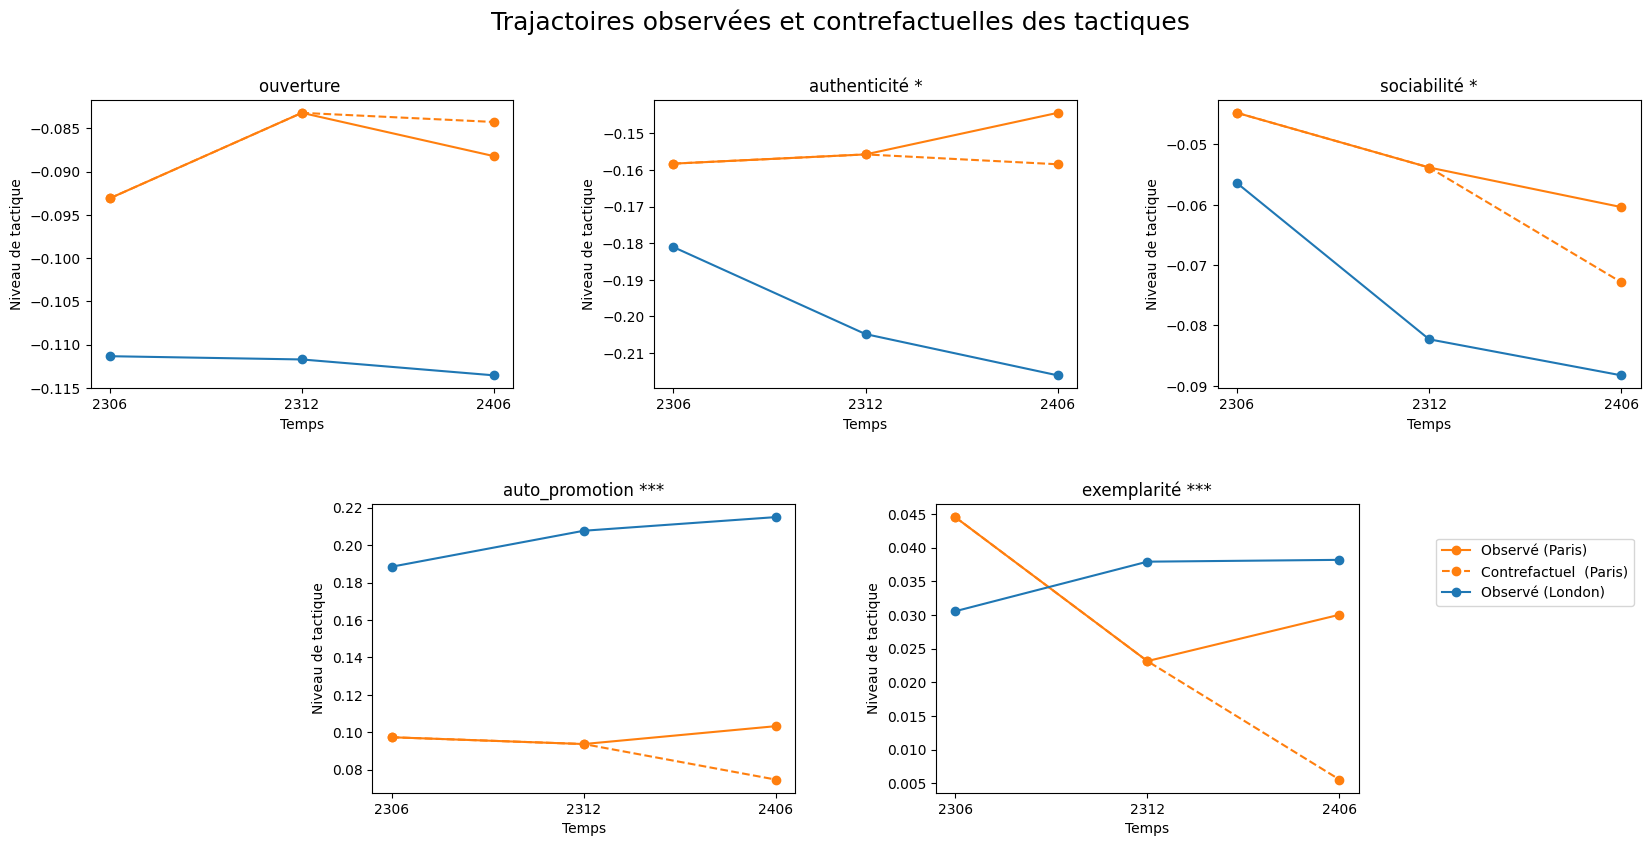

In [48]:
## vis
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.gridspec as gridspec


# ---layout---
# 使用更细的列分辨率（2 行 × 6 列），方便把第二行两个图放在中间列
fig = plt.figure(figsize=(20,9))# sharey=True
gs = gridspec.GridSpec(2, 6, figure=fig, hspace=0.4, wspace=1)

axes = []
# 第一行三个：分别占两列宽 (0:2, 2:4, 4:6)
ax1 = fig.add_subplot(gs[0, 0:2])
ax2 = fig.add_subplot(gs[0, 2:4])
ax3 = fig.add_subplot(gs[0, 4:6])
axes.extend([ax1, ax2, ax3])

# 第二行两个：让它们居中，分别占中间的两列 (1:3 和 3:5)
ax4 = fig.add_subplot(gs[1, 1:3])
ax5 = fig.add_subplot(gs[1, 3:5])
axes.extend([ax4, ax5])

# 确保 tactics_vars 长度为 5（或小于等于 len(axes)）
n_to_plot = min(len(tactics_bio), len(axes))

# ---plot---
for i, var in enumerate(tactics_bio):
    print(var)
    agg=agg_all[agg_all['variable']==var]
    # display(agg)
    
    ax=axes[i]
    
    # categorical mapping
    times = sorted(agg["time"].unique())
    time_map = {t: i for i, t in enumerate(times)}

    paris = agg[agg["in_paris"] == 1]    
    ax.plot(
        paris["time"].map(time_map),
        paris["y_hat"],
        marker="o",
        label="Observé (Paris)",
            color='tab:orange'
    )

    ax.plot(
        paris["time"].map(time_map),
        paris["y_cf"],
        marker="o",
        linestyle="--",
        label="Contrefactuel  (Paris)",
        color='tab:orange'
    )

    control = agg[agg["in_paris"] == 0]
    ax.plot(
        control["time"].map(time_map),
        control["y_hat"],
        marker="o",
        # alpha=0.4,
        label="Observé (London)",
        color='tab:blue'
    )

    # event line
    # ax.axvline(time_map[2406], color="red", linestyle="--")
    # x-axis as labels (equal spacing!)
    ax.set_xticks(list(time_map.values()))
    ax.set_xticklabels(list(time_map.keys()))

    # ax.legend()
    
    var_sig=p_to_sig(pval_dict.get(var))
    ax.set_title(f"{var} {var_sig}")
    ax.set_ylabel("Niveau de tactique")
    ax.set_xlabel("Temps")
    # ax.set_ylabel("Outcome")
    # break

fig.suptitle(
        "Trajactoires observées et contrefactuelles des tactiques",
        fontsize=18,
        y=0.98
    )

# plt.legend()
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper right",
    # ncol=2
    bbox_to_anchor=(0.9,0.4)
)

# plt.legend()
plt.tight_layout(rect=[0, 0, 1,1])
plt.show()

In [94]:
ttest=model.t_test("in_paris:C(time)[T.2406] - in_paris:C(time)[T.2312] = 0")
ttest.effect, p_to_sig(ttest.pvalue)

(array([-0.02779377]), '***')

# booking_rate~

In [128]:
# df_2324=df_all[df_all['time']!=2312]
# print(df_2324[['in_paris','time']].value_counts(dropna=False))

df=df_all.copy()

formula= ("booking_rate_l90d ~ C(host_identity_verified)  + review_scores_rating + has_rating +"
        "number_of_reviews_ltm + "
        "C(host_is_superhost) +"
        "years_since_host + professional_host + "
        "host_response_rate +  C(host_response_time)+"
        "has_text + lang_en + lang_fr + text_length+"
        "price  + availability_90 + C(room_type) + C(instant_bookable) + "
        
        "ouverture + authenticité + sociabilité + auto_promotion + exemplarité +"
        "C(host_picture_type) +"
        "C(time) + in_paris*C(time)"
)
        # "pic_no_person + pic_pro_style + pic_life_style +"
        # " is_smiling + "
        # "C(age_class) + C(gender) +"
df=df_all.copy()
model_basic=smf.ols(formula, data=df).fit()
summary=model_basic.summary()
print(summary)


                            OLS Regression Results                            
Dep. Variable:      booking_rate_l90d   R-squared:                       0.399
Model:                            OLS   Adj. R-squared:                  0.399
Method:                 Least Squares   F-statistic:                     4985.
Date:                Tue, 07 Apr 2026   Prob (F-statistic):               0.00
Time:                        20:36:01   Log-Likelihood:                 82315.
No. Observations:              254981   AIC:                        -1.646e+05
Df Residuals:                  254946   BIC:                        -1.642e+05
Df Model:                          34                                         
Covariance Type:            nonrobust                                         
                                                  coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------

In [129]:
var="booking_rate_l90d"
data_booking=get_event_study_data(model=model_basic, var=var)
display(data_booking)
print(data_booking.time.dtype)
jo_effect=get_jo_effect(model, var=var)
jo_effect

,time,coef,ci_low,ci_high,variable,se,pval,sig,label
0,2306,0.000000,0.000000,0.000000,booking_rate_l90d,NaN,NaN,,2306
1,2312,-0.029828,-0.033424,-0.026232,booking_rate_l90d,0.001835,2.110949e-59,***,2312 ***
2,2406,-0.057621,-0.060975,-0.054268,booking_rate_l90d,0.001711,3.968165e-248,***,2406 ***


object


{'variable': 'booking_rate_l90d',
 'coef': np.float64(-0.02779376895732288),
 'se': array([0.00168334]),
 'pval': array(3.28388652e-61),
 'sig': '***',
 'ci_low': np.float64(-0.031093063051468178),
 'ci_high': np.float64(-0.024494474863177584)}

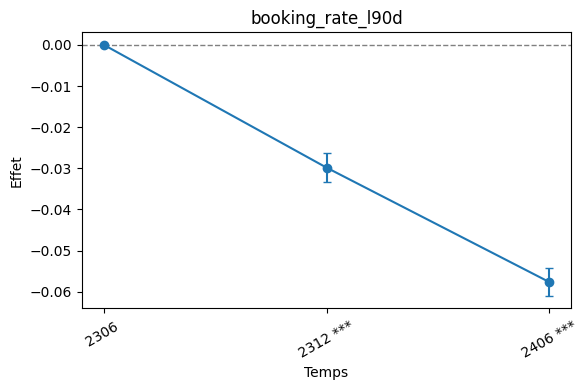

In [130]:
df = data_booking.copy()
var = 'booking_rate_l90d'

fig, ax = plt.subplots(figsize=(6, 4))

sub = df[df["variable"] == var].copy()

# 👉 保持 categorical
sub["time"] = sub["time"].astype(str)
sub = sub.sort_values("time")

# baseline
sub.loc[sub["time"] == "2306", ["coef", "ci_low", "ci_high"]] = 0

# errorbar
ax.errorbar(
    # sub["time"],
    sub['label'],
    sub["coef"],
    yerr=[
        sub["coef"] - sub["ci_low"],
        sub["ci_high"] - sub["coef"]
    ],
    fmt='-o',
    capsize=3
)

# reference line
ax.axhline(0, linestyle="--", color="gray", linewidth=1)

# 美化
ax.set_xlabel("Temps")
ax.set_ylabel("Effet")
ax.set_title(var)
ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

In [131]:
df=df_all.copy()
model=model_basic

# ---pred---
df["y_hat"] = model.predict(df)
# ^ : 带“帽子”（hat）的变量 = 估计值 / 预测值
## actual observed ~= (predicted) observed

delta_2406 = model.params["in_paris:C(time)[T.2406]"]
delta_2312 = model.params["in_paris:C(time)[T.2312]"]

adjustment = delta_2406 - delta_2312
print(f'effet JO:{adjustment}')


df["y_cf"] = df["y_hat"]

df.loc[
    (df["in_paris"]==1) & (df["time"]==2406),
    "y_cf"
] -= adjustment

# ---agg--- 
# agg = df.copy()

# agg = agg.groupby(["time","in_paris"], as_index=False).agg({
#     "y_hat":"mean",
#     "y_cf":"mean"
# }).sort_values("time")

# agg

display(df[['y_hat','y_cf']].describe())
agg=df.groupby(['time','in_paris'])[['y_hat','y_cf']].mean().reset_index()
print(agg)

var_sig= p_to_sig(model.t_test(
            "in_paris:C(time)[T.2406] - in_paris:C(time)[T.2312] = 0"
        ).pvalue)
print(var_sig)

effet JO:-0.02779376895732288


,y_hat,y_cf
count,254981.000000,254981.000000
mean,0.119887,0.126394
std,0.142859,0.141412
min,-0.341918,-0.333223
25%,0.008675,0.016726
50%,0.112484,0.121730
75%,0.211683,0.216369
max,4.451266,4.451266


   time  in_paris     y_hat      y_cf
0  2306         0  0.165077  0.165077
1  2306         1  0.214623  0.214623
2  2312         0  0.073889  0.073889
3  2312         1  0.103226  0.103226
4  2406         0  0.122569  0.122569
5  2406         1  0.077640  0.105434
***


Text(0.5, 0, 'Temps')

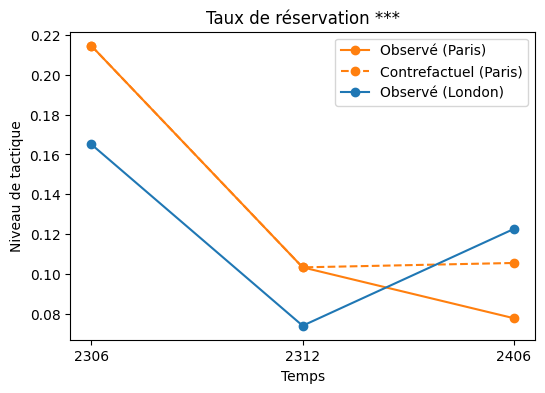

In [132]:
# agg=agg_all[agg_all['variable']==var]
    # display(agg)
    
fig, ax=plt.subplots(figsize=(6, 4))
# categorical mapping
times = sorted(agg["time"].unique())
time_map = {t: i for i, t in enumerate(times)}

paris = agg[agg["in_paris"] == 1]    
ax.plot(
    paris["time"].map(time_map),
    paris["y_hat"],
    marker="o",
    label="Observé (Paris)",
        color='tab:orange'
)

ax.plot(
    paris["time"].map(time_map),
    paris["y_cf"],
    marker="o",
    linestyle="--",
    label="Contrefactuel (Paris)",
    color='tab:orange'
)

control = agg[agg["in_paris"] == 0]
ax.plot(
    control["time"].map(time_map),
    control["y_hat"],
    marker="o",
    # alpha=0.4,
    label="Observé (London)",
    color='tab:blue'
)

# event line
# ax.axvline(time_map[2406], color="red", linestyle="--")
# x-axis as labels (equal spacing!)
ax.set_xticks(list(time_map.values()))
ax.set_xticklabels(list(time_map.keys()))

# ax.legend()
ax.legend()
# var_sig=p_to_sig(pval_dict.get(var))
ax.set_title(f"Taux de réservation {var_sig}")
ax.set_ylabel("Niveau de tactique")
ax.set_xlabel("Temps")
# ax.set_ylabel("Outcome")
# break

## effets des tactiques

In [139]:
def plot_predict_curve(model, df, var):
    import numpy as np

    # default control values
    default_vals = {}
    for col in model.model.exog_names:
        if ':' in col or col == 'Intercept':
            continue
        var_name = col.split('[')[0].replace('C(', '').replace(')', '')
        if var_name in df.columns:
            if df[var_name].dtype == 'O' or df[var_name].nunique() < 10:
                default_vals[var_name] = df[var_name].mode()[0]
            else:
                default_vals[var_name] = df[var_name].mean()
    tactic_range = np.linspace(df[var].min(), df[var].max(), 100)

    rows = []
    for val in tactic_range:
        row = default_vals.copy()
        row[var] = val
        rows.append(row)

    pred_df = pd.DataFrame(rows)

    # type alignment
    for col in pred_df.columns:
        if col in df.columns:
            pred_df[col] = pred_df[col].astype(df[col].dtype)

    preds = model.get_prediction(pred_df)
    sf = preds.summary_frame(alpha=0.05)

    pred_df["y"] = sf["mean"]
    pred_df["low"] = sf["mean_ci_lower"]
    pred_df["high"] = sf["mean_ci_upper"]

    return pred_df

In [144]:
pred_df= plot_predict_curve(model, df,  var="authenticité")
pred_df.columns.to_list()

['host_identity_verified',
 'host_is_superhost',
 'host_response_time',
 'room_type',
 'instant_bookable',
 'host_picture_type',
 'time',
 'review_scores_rating',
 'has_rating',
 'number_of_reviews_ltm',
 'years_since_host',
 'professional_host',
 'host_response_rate',
 'has_text',
 'lang_en',
 'lang_fr',
 'text_length',
 'price',
 'availability_90',
 'ouverture',
 'authenticité',
 'sociabilité',
 'auto_promotion',
 'exemplarité',
 'in_paris',
 'y',
 'low',
 'high']

In [147]:
def plot_predict_curve_fast(model, df, var, sample_n=5000):
    import numpy as np
    import pandas as pd

    # ✅ 抽样
    base = df.sample(sample_n, random_state=0).copy()

    grid = np.linspace(df[var].min(), df[var].max(), 100)

    pred_list = []

    for val in grid:
        base[var] = val
        yhat = model.predict(base)   # 🚀 更快
        pred_list.append(yhat.mean())

    return pd.DataFrame({
        var: grid,
        "y": pred_list
    })
pred_df= plot_predict_curve(model, df,  var="authenticité")
pred_df.columns.to_list()
pred_df

,host_identity_verified,host_is_superhost,host_response_time,room_type,instant_bookable,host_picture_type,time,review_scores_rating,has_rating,number_of_reviews_ltm,...,availability_90,ouverture,authenticité,sociabilité,auto_promotion,exemplarité,in_paris,y,low,high
0,t,f,within an hour,Entire home/apt,f,pro_style,2406,4.735862,1,8.702948,...,49.34868,-0.10035,-2.053085,-0.065702,0.15251,0.033779,0,0.135317,0.131169,0.139465
1,t,f,within an hour,Entire home/apt,f,pro_style,2406,4.735862,1,8.702948,...,49.34868,-0.10035,-2.014349,-0.065702,0.15251,0.033779,0,0.135410,0.131295,0.139526
2,t,f,within an hour,Entire home/apt,f,pro_style,2406,4.735862,1,8.702948,...,49.34868,-0.10035,-1.975614,-0.065702,0.15251,0.033779,0,0.135504,0.131420,0.139589
3,t,f,within an hour,Entire home/apt,f,pro_style,2406,4.735862,1,8.702948,...,49.34868,-0.10035,-1.936879,-0.065702,0.15251,0.033779,0,0.135598,0.131545,0.139651
4,t,f,within an hour,Entire home/apt,f,pro_style,2406,4.735862,1,8.702948,...,49.34868,-0.10035,-1.898144,-0.065702,0.15251,0.033779,0,0.135692,0.131669,0.139714
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,t,f,within an hour,Entire home/apt,f,pro_style,2406,4.735862,1,8.702948,...,49.34868,-0.10035,1.626766,-0.065702,0.15251,0.033779,0,0.144220,0.140462,0.147978
96,t,f,within an hour,Entire home/apt,f,pro_style,2406,4.735862,1,8.702948,...,49.34868,-0.10035,1.665501,-0.065702,0.15251,0.033779,0,0.144313,0.140528,0.148098
97,t,f,within an hour,Entire home/apt,f,pro_style,2406,4.735862,1,8.702948,...,49.34868,-0.10035,1.704236,-0.065702,0.15251,0.033779,0,0.144407,0.140595,0.148219
98,t,f,within an hour,Entire home/apt,f,pro_style,2406,4.735862,1,8.702948,...,49.34868,-0.10035,1.742971,-0.065702,0.15251,0.033779,0,0.144501,0.140661,0.148341


In [ ]:
# var='authenticité'
# coef = model.params[var]
# se = model.bse[var]
# pval = model.pvalues[var]
# print(coef, se, pval)

0.002419344594841981 0.0006528089951235054 0.0002105589308765708


In [ ]:
# def plot_predict_curve(model, df, var):
#     import numpy as np
#     import pandas as pd

#     # 用真实数据的均值行（更稳）
#     base = df.copy()

#     # 构造 grid
#     grid = np.linspace(df[var].min(), df[var].max(), 100)

#     pred_list = []

#     for val in grid:
#         temp = base.copy()
#         temp[var] = val

#         preds = model.get_prediction(temp).summary_frame()
#         pred_list.append(preds["mean"].mean())

#     return pd.DataFrame({
#         var: grid,
#         "y": pred_list
#     })

C:\Users\yeliu\AppData\Local\Temp\ipykernel_20272\3721209017.py:36: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()#on ax
C:\Users\yeliu\AppData\Local\Temp\ipykernel_20272\3721209017.py:36: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()#on ax
C:\Users\yeliu\AppData\Local\Temp\ipykernel_20272\3721209017.py:36: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()#on ax
C:\Users\yeliu\AppData\Local\Temp\ipykernel_20272\3721209017.py:36: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with n

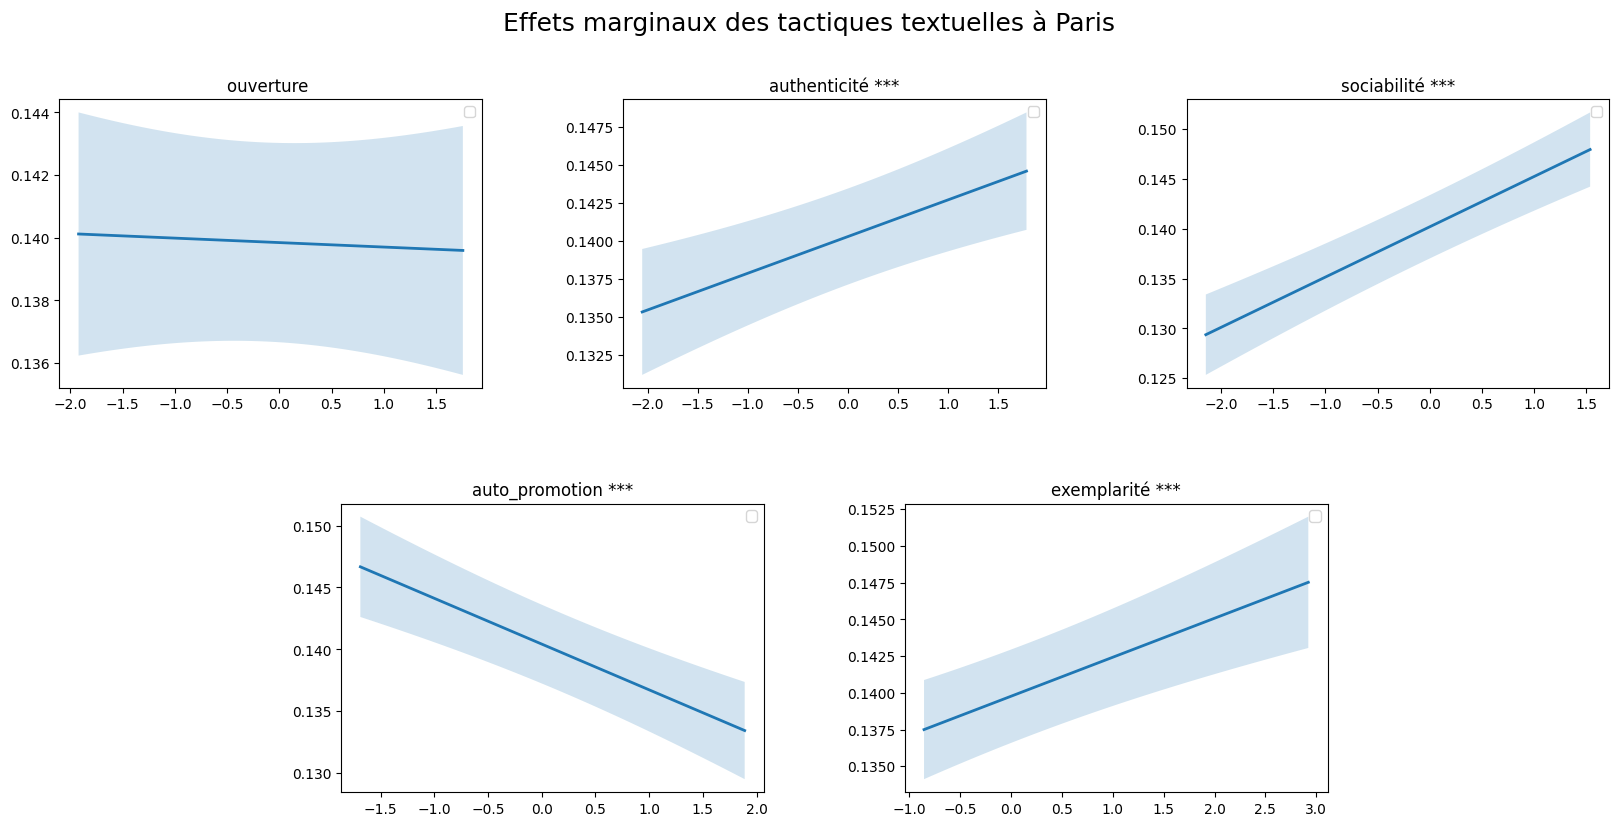

In [ ]:
df=df_all.copy()
model=model_basic

# -------------------layout-------------------
# 使用更细的列分辨率（2 行 × 6 列），方便把第二行两个图放在中间列
fig = plt.figure(figsize=(20,9))
gs = gridspec.GridSpec(2, 6, figure=fig, hspace=0.4, wspace=1)

axes = []
# 第一行三个：分别占两列宽 (0:2, 2:4, 4:6)
ax1 = fig.add_subplot(gs[0, 0:2])
ax2 = fig.add_subplot(gs[0, 2:4])
ax3 = fig.add_subplot(gs[0, 4:6])
axes.extend([ax1, ax2, ax3])

# 第二行两个：让它们居中，分别占中间的两列 (1:3 和 3:5)
ax4 = fig.add_subplot(gs[1, 1:3])
ax5 = fig.add_subplot(gs[1, 3:5])
axes.extend([ax4, ax5])

# 确保 tactics_vars 长度为 5（或小于等于 len(axes)）
n_to_plot = min(len(tactics_bio), len(axes))


# city='paris'
# times=['2024',"2023"]


for i, var in enumerate(tactics_bio):
    ax = axes[i]
    # for time in times:
    pred_df = plot_predict_curve(model, df, var)
    sig=p_to_sig(model.pvalues[var])
    ax.plot(pred_df[var], pred_df["y"], linewidth=2)
    ax.fill_between(pred_df[var], pred_df["low"], pred_df["high"], alpha=0.2)
    ax.legend()#on ax
    ax.set_title(f"{var} {sig}")

fig.suptitle(
        "Effets marginaux des tactiques textuelles à Paris",
        fontsize=18,
        y=0.98
    )
plt.tight_layout()
plt.show()

In [178]:
def p_to_sig(p):
    if p < 0.001: return '***'
    elif p < 0.01: return '**'
    elif p < 0.05: return '*'
    elif p < 0.1: return '.'
    else: return ''
    
def plot_categorical_effect(model, df, var, sample_n=5000):
    import pandas as pd
    
    # ✅ 抽样（关键！）
    base = df.sample(sample_n, random_state=0).copy()
    
    categories = df[var].dropna().unique()
    
    results = []
    for cat in categories:
        print(cat)
        
        base[var] = cat
        yhat = model.predict(base)   # 🚀 快很多
        term=f"C({var})[T.{cat}]"
        
        if term not in list(model.params.index):
            sig = ""
        else:   
            sig = p_to_sig(float(model.pvalues[term]))
        
        
        results.append({
            var: cat,
            "y": yhat.mean(),
            "sig": sig
        })
    return pd.DataFrame(results)


pred_df = plot_categorical_effect(model, df, "host_picture_type")
display(pred_df)


# ax.scatter(pred_df["host_picture_type"], pred_df["y"], s=80)

# for i, row in pred_df.iterrows():
#     ax.text(i, row["y"], f"{row['y']:.3f}", ha='center')

# ax.set_title("Effect of host_picture_type")
# ax.set_ylabel("Predicted booking_rate")


# ax.bar(pred_df["host_picture_type"], pred_df["y"])
# ax.set_title("Effect of host_picture_type")



life_style
pro_style
no_person


,host_picture_type,y,sig
0,life_style,0.116000,
1,pro_style,0.118385,**
2,no_person,0.107376,***


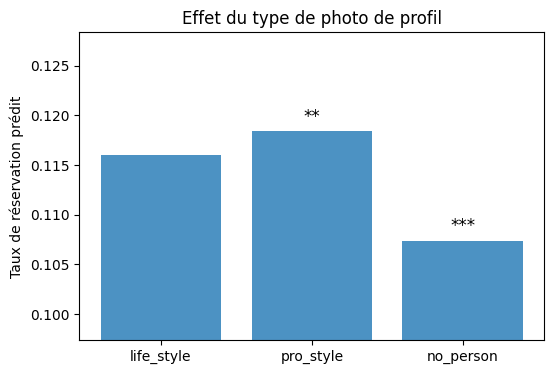

In [ ]:
def plot_cat_effect(df_plot):
    import matplotlib.pyplot as plt

    plt.figure(figsize=(6,4))

    ax = plt.gca()

    ax.bar(df_plot["host_picture_type"], df_plot["y"], alpha=0.8)

    for i, row in df_plot.iterrows():
        ax.text(i, row["y"] + 0.001, row["sig"],
                ha='center', fontsize=12)

    ax.set_ylabel("Taux de réservation prédit")
    ax.set_title("Effet du type de photo de profil")

    plt.ylim(min(df_plot["y"]) - 0.01, max(df_plot["y"]) + 0.01)
    plt.show()
plot_cat_effect(pred_df)

## model inetraction

In [189]:
df=df_all.copy()
formula= ("booking_rate_l90d ~ C(host_identity_verified)  + review_scores_rating + has_rating +"
        "number_of_reviews_ltm + "
        "C(host_is_superhost) +"
        "years_since_host + professional_host + "
        "host_response_rate +  +C(host_response_time)+"
        "has_text + lang_en + lang_fr + text_length+"
        "price  + availability_90 + C(room_type) + C(instant_bookable) + "
        "C(host_picture_type) +"
        "C(time) +"
        "in_paris * C(time) *(ouverture + authenticité + sociabilité + auto_promotion + exemplarité)"
        # "pic_no_person + pic_pro_style + pic_life_style +"
        # " is_smiling + "
        # "C(age_class) + C(gender) +"

)
df=df_all.copy()
model_interaction=smf.ols(formula, data=df).fit()
summary=model_interaction.summary()
print(summary)

                            OLS Regression Results                            
Dep. Variable:      booking_rate_l90d   R-squared:                       0.401
Model:                            OLS   Adj. R-squared:                  0.401
Method:                 Least Squares   F-statistic:                     2894.
Date:                Tue, 07 Apr 2026   Prob (F-statistic):               0.00
Time:                        21:27:11   Log-Likelihood:                 82700.
No. Observations:              254981   AIC:                        -1.653e+05
Df Residuals:                  254921   BIC:                        -1.647e+05
Df Model:                          59                                         
Covariance Type:            nonrobust                                         
                                                  coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------

In [191]:
tactics = [
    "ouverture",
    "authenticité",
    "sociabilité",
    "auto_promotion",
    "exemplarité"
]

times = ["2306", "2312", "2406"]

cities = ["London", "Paris"]

base = df.copy()
base_controls = base.copy()

# # 控制变量固定
# control_cols = [所有非tactic / 非交互变量]
# base_controls = base[control_cols].mean().to_frame().T


def build_cf(df, city, time, tactic, value):
    temp = df.copy()

    temp["in_paris"] = 1 if city == "Paris" else 0
    temp["time"] = time

    for t in tactics:
        temp[t] = 0

    temp[tactic] = value

    return temp


results = []
for city in cities:
    for time in times:
        for tactic in tactics:

            df0 = build_cf(base, city, time, tactic, 0)
            df1 = build_cf(base, city, time, tactic, 1)

            y0 = model.predict(df0).mean()
            y1 = model.predict(df1).mean()

            effect = y1 - y0

            results.append({
                "city": city,
                "time": time,
                "tactic": tactic,
                "effect": effect
            })

PatsyError: predict requires that you use a DataFrame when predicting from a model
that was created using the formula api.

The original error message returned by patsy is:
Error converting data to categorical: observation with value '2306' does not match any of the expected levels (expected: [2306, 2312, 2406])
    booking_rate_l90d ~ C(host_identity_verified)  + review_scores_rating + has_rating +number_of_reviews_ltm + C(host_is_superhost) +years_since_host + professional_host + host_response_rate +  C(host_response_time)+has_text + lang_en + lang_fr + text_length+price  + availability_90 + C(room_type) + C(instant_bookable) + ouverture + authenticité + sociabilité + auto_promotion + exemplarité +C(host_picture_type) +C(time) + in_paris*C(time)
                                                                                                                                                                                                                                                  

In [ ]:
def get_event_study_data_var(model):
    import numpy as np
    params = model.params
    bse = model.bse
    pvalues=model.pvalues
    
    # 提取 interaction terms
    data = pd.DataFrame({
        "coef": params,
        "se": bse,
        'pval':pvalues
    }).reset_index()

    data.columns = ["variable", "coef", "se", "pval"]
    
    # 只保留 in_paris × time
    data = data[data["variable"].str.contains(f"in_paris:C\\(time\\)")]
    # pattern = "|".join(tactics_bio)
    # data = data[data["variable"].str.contains(pattern)]
    
    
    # 提取时间点
    data["time"] = data["variable"].str.extract(r"T\.(\d+)")

    # 排序
    data = data.sort_values("time")

    # 置信区间
    data["ci_low"] = data["coef"] - 1.96 * data["se"]
    data["ci_high"] = data["coef"] + 1.96 * data["se"]
    
    # baseline（2306 = 0）
    baseline = pd.DataFrame({
        "time": ["2306"],
        "coef": [0],
        "ci_low": [0],
        "ci_high": [0]
    })


    data = pd.concat([baseline, data], ignore_index=True)

    # 转 numeric
    data["time"] = pd.to_numeric(data["time"])
    data = data.sort_values("time")
    data['time']=data['time'].astype(str)
    
    # display(data)
    data['tactic']= data['variable'].apply(lambda x : str(x).split(':')[-1] if x!=np.nan and str(x).split(':')[-1] in tactics_bio else np.nan)
    data['sig']=data['pval'].apply(p_to_sig)        
    data['label']=data['time']+' '+data['sig']        
    return data

data=get_event_study_data_var(model_interaction)
display(data)

,time,coef,ci_low,ci_high,variable,se,pval,tactic,sig,label
0,2306,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,,2306
1,2312,-0.028463,-0.032198,-0.024727,in_paris:C(time)[T.2312],0.001906,2.072115e-50,NaN,***,2312 ***
2,2312,0.004478,-0.001902,0.010858,in_paris:C(time)[T.2312]:ouverture,0.003255,1.689162e-01,ouverture,,2312
3,2312,0.000858,-0.005524,0.007240,in_paris:C(time)[T.2312]:authenticité,0.003256,7.921549e-01,authenticité,,2312
4,2312,-0.007041,-0.013237,-0.000845,in_paris:C(time)[T.2312]:sociabilité,0.003161,2.592578e-02,sociabilité,*,2312 *
5,2312,0.010291,0.003887,0.016695,in_paris:C(time)[T.2312]:auto_promotion,0.003267,1.634425e-03,auto_promotion,**,2312 **
6,2312,-0.004604,-0.010560,0.001352,in_paris:C(time)[T.2312]:exemplarité,0.003039,1.297540e-01,exemplarité,,2312
7,2406,-0.060458,-0.063947,-0.056969,in_paris:C(time)[T.2406],0.001780,2.931487e-252,NaN,***,2406 ***
8,2406,0.001352,-0.004549,0.007253,in_paris:C(time)[T.2406]:ouverture,0.003011,6.534620e-01,ouverture,,2406
9,2406,-0.010612,-0.016548,-0.004676,in_paris:C(time)[T.2406]:authenticité,0.003029,4.584949e-04,authenticité,***,2406 ***


In [ ]:
## PARAMS
res = model_interaction
params = res.params
cov = res.cov_params()
strategies = ["ouverture", "authenticité", "sociabilité", "auto_promotion", "exemplarité"]
times = ["2306", '2312', "2406"]


In [ ]:
import pandas as pd
import numpy as np

def get_effect(res, strategy, time):

    base = f"{strategy}"
    t = f"C(time)[T.{time}]:{strategy}"
    p = f"in_paris:C(time)[T.{time}]:{strategy}"

    coef = 0
    var = 0

    terms = []
    
    # 找到三个相关term的coef
    for term in [base, t, p]:
        if term in res.params.index:
            coef += res.params[term]
            terms.append(term)

    # variance (Delta method)
    for i in terms:
        for j in terms:
            if i in res.params.index and j in res.params.index:
                var += res.cov_params().loc[i, j]

    se = np.sqrt(var)

    return coef, se

In [ ]:
rows = []
for s in strategies:
    for t in times:
        # print(s, t)
        coef, se = get_effect(res, s, t)

        rows.append({
            "variable": s,
            "time": t,
            "effect": coef,
            "se": se,
            "ci_low": coef - 1.96*se,
            "ci_high": coef + 1.96*se
        })
    #     break
    # break

df_plot = pd.DataFrame(rows)
df_plot

,variable,time,effect,se,ci_low,ci_high
0,ouverture,2306,0.000466,0.001501,-0.002477,0.003409
1,ouverture,2312,0.004608,0.002880,-0.001037,0.010252
2,ouverture,2406,0.004178,0.002650,-0.001016,0.009373
3,authenticité,2306,0.011157,0.001500,0.008217,0.014096
4,authenticité,2312,-0.006947,0.002888,-0.012608,-0.001286
5,authenticité,2406,-0.007376,0.002683,-0.012635,-0.002117
6,sociabilité,2306,0.010051,0.001399,0.007309,0.012793
7,sociabilité,2312,-0.006222,0.002833,-0.011774,-0.000670
8,sociabilité,2406,-0.007355,0.002607,-0.012465,-0.002245
9,auto_promotion,2306,-0.008856,0.001461,-0.011718,-0.005993


C:\Users\yeliu\AppData\Local\Temp\ipykernel_20272\1416556135.py:68: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


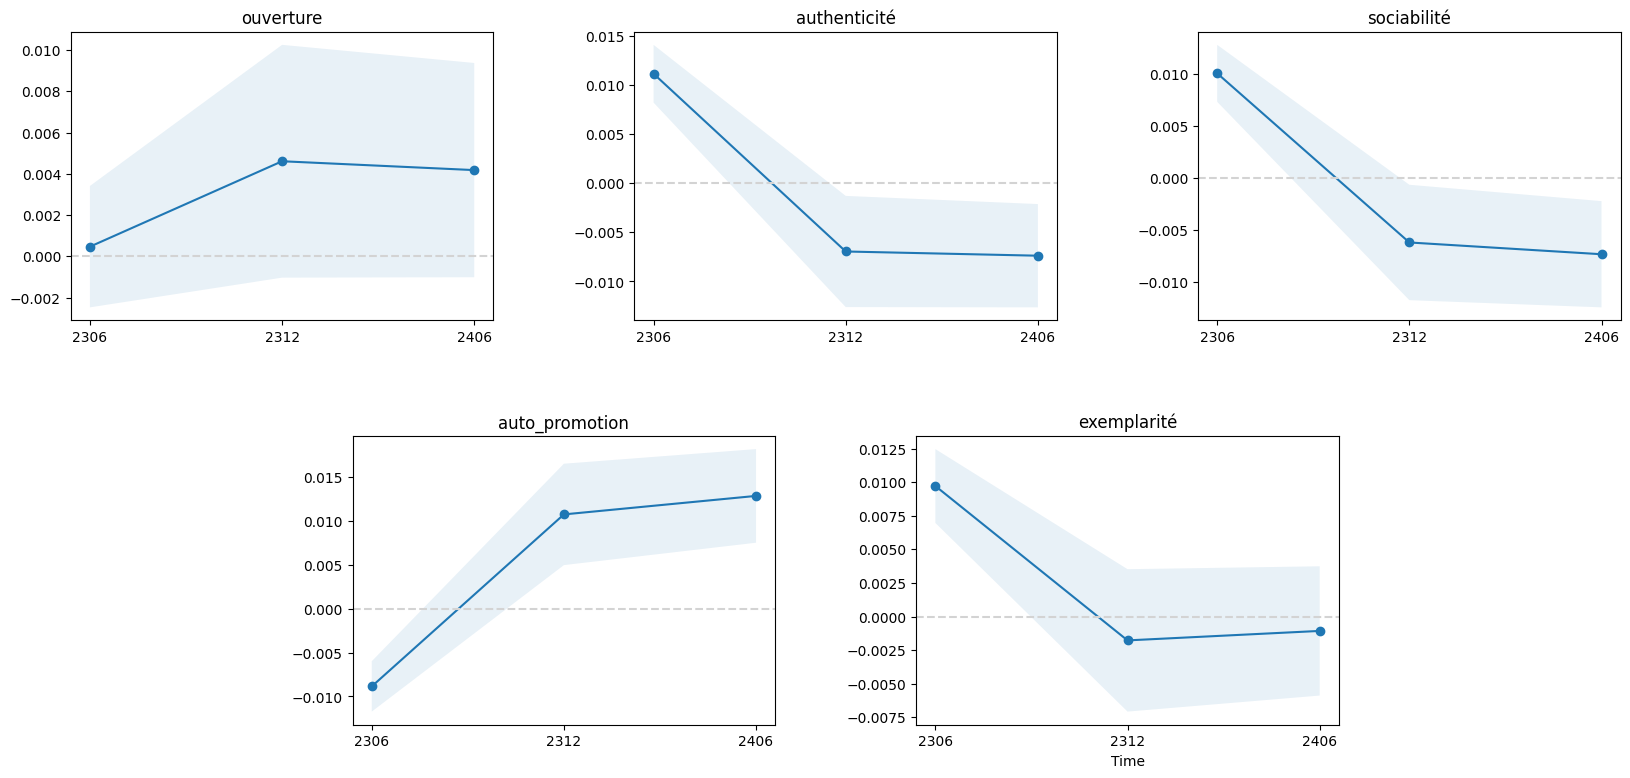

In [ ]:
#👉 Paris 相对于 London，在每个 time 下 strategy 的边际效应
# ❗ JO 是否改变“策略 → 预订率”的回报结构？
# Effect k,t ​= βstrategy,k ​+ βtime × strategy ​+ βinparis × time × strategy​


import matplotlib.pyplot as plt
import seaborn as sns

def plot_strategy_multiples(df):
    df['time']=df['time'].astype(str)
    vars = df["variable"].unique()

    
    # ---layout---
    # 使用更细的列分辨率（2 行 × 6 列），方便把第二行两个图放在中间列
    fig = plt.figure(figsize=(20,9))# sharey=True
    gs = gridspec.GridSpec(2, 6, figure=fig, hspace=0.4, wspace=1)

    axes = []
    # 第一行三个：分别占两列宽 (0:2, 2:4, 4:6)
    ax1 = fig.add_subplot(gs[0, 0:2])
    ax2 = fig.add_subplot(gs[0, 2:4])
    ax3 = fig.add_subplot(gs[0, 4:6])
    axes.extend([ax1, ax2, ax3])

    # 第二行两个：让它们居中，分别占中间的两列 (1:3 和 3:5)
    ax4 = fig.add_subplot(gs[1, 1:3])
    ax5 = fig.add_subplot(gs[1, 3:5])
    axes.extend([ax4, ax5])

    for i, var in enumerate(vars):
        sub = df[df["variable"] == var]#.sort_values("time")
         
        # display(sub)
        ax = axes[i]

        # line
        ax.plot(sub["time"], sub["effect"], marker="o")

        # CI band
        ax.fill_between(
            sub["time"],
            sub["ci_low"],
            sub["ci_high"],
            alpha=0.1
        )

        # 标题
        ax.set_title(var)

        # JO 标记
        # ax.axvline("2406", linestyle="--")
        # ax.text("2406", ax.get_ylim()[1]*0.9, "JO")

        ax.axhline(0, linestyle="--", color="lightgray")
        # break
    
    plt.xlabel("Temps")
    plt.tight_layout()
    plt.show()
    
    
plot_strategy_multiples(df_plot)